In [1]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ShwetaAmale\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ShwetaAmale\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [2]:
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

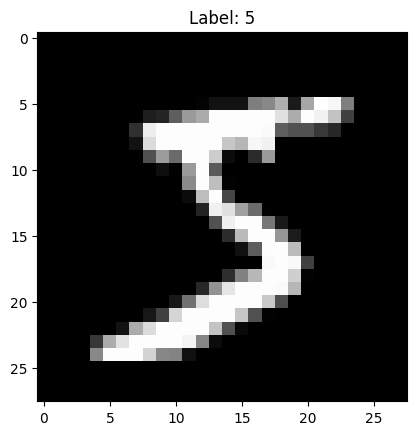

In [3]:
plt.imshow(x_train[0], cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.show()

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
(c_train, y_train), (x_test, y_test) = mnist.load_data()

In [5]:
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1).astype('float32')
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1).astype('float32')

In [6]:
x_train /= 255
x_test /= 255

In [7]:
from tensorflow.keras.models import Sequential

In [8]:
from tensorflow.keras.layers import Dense, Flatten

In [9]:
model = Sequential()

In [10]:
model.add(Flatten(input_shape=(28, 28, 1)))

C:\Users\ShwetaAmale\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [11]:
model.add(Dense(128, activation='relu'))

In [12]:
model.add(Dense(10, activation='softmax'))

In [13]:
model.compile(
    optimizer='adam',
    loss = 'sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [14]:
model.fit(x_train, y_train, epochs=5, batch_size=128, validation_split=0.2)

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8890 - loss: 0.3994 - val_accuracy: 0.9417 - val_loss: 0.2102
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9465 - loss: 0.1862 - val_accuracy: 0.9527 - val_loss: 0.1617
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9614 - loss: 0.1353 - val_accuracy: 0.9609 - val_loss: 0.1330
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9699 - loss: 0.1054 - val_accuracy: 0.9678 - val_loss: 0.1124
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9758 - loss: 0.0842 - val_accuracy: 0.9689 - val_loss: 0.1056


In [15]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {test_accuracy}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9708 - loss: 0.0975
Test Accuracy: 0.97079998254776


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


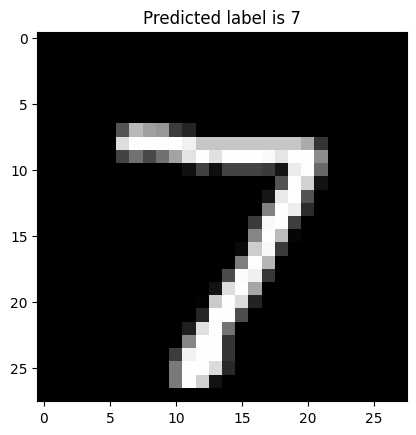

In [16]:
predictions = model.predict(x_test)
plt.imshow(x_test[0].reshape(28, 28), cmap='gray')
plt.title(f"Predicted label is {predictions[0].argmax()}")
plt.show()

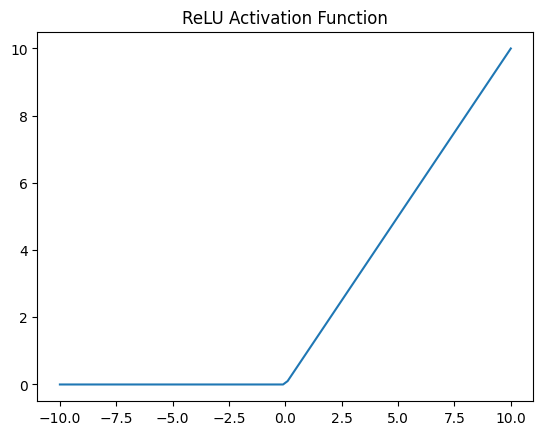

In [17]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-10, 10, 100)
y = np.maximum(0, x)
plt.plot(x, y)
plt.title("ReLU Activation Function")
plt.show()

Logits: [2.  1.  0.1]
Softmax Output: [0.65900114 0.24243297 0.09856589]
Sum of probabilities: 1.0


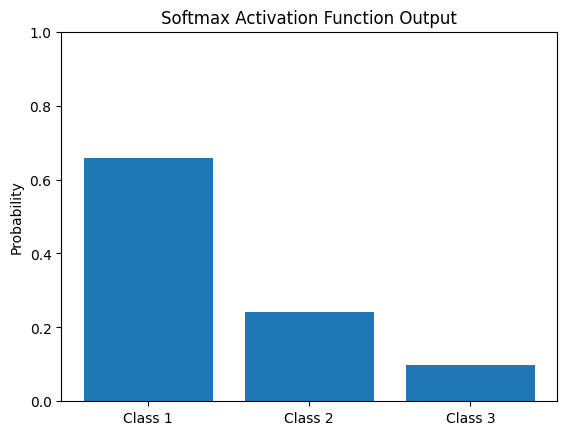

In [18]:
import numpy as np
import matplotlib.pyplot as plt
# Sample logits (raw neural network outputs)
logits = np.array([2.0, 1.0, 0.1])
# Softmax formula: e^x / sum(e^x)
exp_logits = np.exp(logits)
softmax_output = exp_logits / np.sum(exp_logits)
print(f"Logits: {logits}")
print(f"Softmax Output: {softmax_output}")
print(f"Sum of probabilities: {np.sum(softmax_output)}")
# Visualization of Softmax for multiple classes
classes = ['Class 1', 'Class 2', 'Class 3']
plt.bar(classes, softmax_output)
plt.ylabel('Probability')
plt.title('Softmax Activation Function Output')
plt.ylim(0, 1)
plt.show()

In [18]:
from tensorflow.keras.datasets import mnist

In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical

In [20]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1).astype('float32') / 255
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1).astype('float32') / 255

In [21]:
model = Sequential()
model.add(Flatten(input_shape=(28, 28, 1)))
model.add(Dense(128, activation='relu'))
model.add(Dense(10, activation='softmax'))

In [22]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [23]:
model.fit(X_train, y_train, epochs=5, batch_size=128, validation_split=0.2)

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.8917 - loss: 0.3946 - val_accuracy: 0.9377 - val_loss: 0.2179
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.9469 - loss: 0.1861 - val_accuracy: 0.9557 - val_loss: 0.1600
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.9613 - loss: 0.1360 - val_accuracy: 0.9617 - val_loss: 0.1349
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9704 - loss: 0.1055 - val_accuracy: 0.9643 - val_loss: 0.1212
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9749 - loss: 0.0859 - val_accuracy: 0.9694 - val_loss: 0.1048


In [24]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Accuracy: {test_accuracy}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9714 - loss: 0.0978
Accuracy: 0.9714000225067139


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


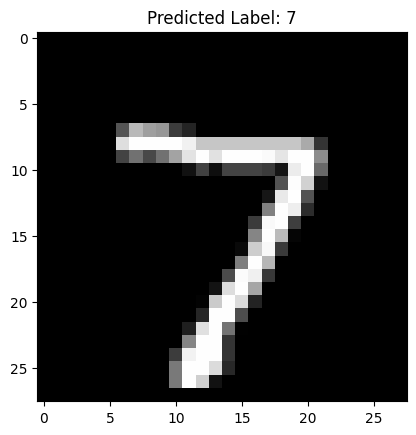

In [25]:
import numpy as np
import matplotlib.pyplot as plt

predictions = model.predict(X_test)
plt.imshow(X_test[0].reshape(28, 28), cmap='gray')
plt.title(f"Predicted Label: {np.argmax(predictions[0])}")
plt.show()

In [26]:
from nltk.tokenize import word_tokenize
sentence = "I love this movie!"
tokens = word_tokenize(sentence)
print(tokens)

['I', 'love', 'this', 'movie', '!']


In [27]:
from nltk.stem import PorterStemmer
stemmer = PorterStemmer()
print(stemmer.stem("running"))
print(stemmer.stem("standing"))

run
stand


In [28]:
from nltk.stem import WordNetLemmatizer
 
lemmatizer = WordNetLemmatizer()
print(lemmatizer.lemmatize("running", pos='v'))
print(lemmatizer.lemmatize("better", pos='a'))

run
good


In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer
corpus = ["I love this movie", "This movie is terrible"]
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(corpus)
print(X.toarray())

[[0.         0.70490949 0.50154891 0.         0.50154891]
 [0.57615236 0.         0.40993715 0.57615236 0.40993715]]


In [30]:
from transformers import pipeline

sentiment_pipeline = pipeline("sentiment-analysis")
print(sentiment_pipeline("I love this movie"))

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.


Device set to use cpu


[{'label': 'POSITIVE', 'score': 0.9998766183853149}]


In [31]:
from transformers import Trainer, TrainingArguments

training_args = TrainingArguments(output_dir="./results", num_train_epochs=3)
trainer = Trainer(model=model, args=training_args, train_dataset=custom_train_dataset, eval_dataset=custom_eval_dataset)

trainer.train()

NameError: name 'custom_train_dataset' is not defined

In [32]:
import tensorflow_datasets as tfds
(train_data, test_data), info = tfds.load("imdb_reviews", split=["train", "test"], with_info=True, as_supervised=True)

In [34]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer(num_words=1000, oov_token="<OOV>")

texts = [
    text.numpy().decode("utf-8") if hasattr(text, "numpy") else str(text)
    for text, label in train_data
]

tokenizer.fit_on_texts(texts)

sequences = tokenizer.texts_to_sequences(texts)

padded_sequences = pad_sequences(
    sequences,
    maxlen=120,
    padding="post",
    truncating="post"
)

print(padded_sequences.shape)

(25000, 120)


In [35]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

In [36]:
model = Sequential([
       Embedding(input_dim=10000, output_dim=64, input_length=120),
       LSTM(64),
       Dense(1, activation='sigmoid')
])

C:\Users\ShwetaAmale\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [37]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [42]:
model.fit(padded_sequences, train_labels, epochs=5, validation_data=(padded_test_sequences, test_labels))

NameError: name 'padded_test_sequences' is not defined

In [39]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [40]:
predictions = model.predict(padded_test_sequences)
predictions = (predictions > 0.5).astype(int)

NameError: name 'padded_test_sequences' is not defined

In [41]:
train_labels = []

for text, label in train_data:
    train_labels.append(label.numpy())

train_labels = np.array(train_labels)

In [43]:
from transformers import pipeline
sentiment_pipeline = pipeline('sentiment-analysis')


No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cpu


In [44]:
texts = ["I love this movie", "This movie was terrible"]

In [45]:
results = sentiment_pipeline(texts)
for text, result in zip(texts, results):
  print(f"Text: {text }, Sentiment: {result['label']}, Score: {result['score']}")

Text: I love this movie, Sentiment: POSITIVE, Score: 0.9998766183853149
Text: This movie was terrible, Sentiment: NEGATIVE, Score: 0.9996950626373291


In [46]:
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [48]:
(train_data, test_data), info = tfds.load('imdb_reviews', split=['train', 'test'], with_info=True, as_supervised=True)

In [51]:
train_texts = [
    text.numpy().decode("utf-8")
    for text, label in train_data
]
# Create tokenizer
tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")

# Fit tokenizer on normal strings
tokenizer.fit_on_texts(train_texts)

# Convert text to integer sequences
train_sequences = tokenizer.texts_to_sequences(train_texts)

# Pad sequences
train_padded = pad_sequences(
    train_sequences,
    maxlen=120,
    padding="post",
    truncating="post"
)

print("Training sequences:", train_padded.shape)
print("Training labels:", train_labels.shape)

Training sequences: (25000, 120)
Training labels: (25000,)


In [52]:
model = tf.keras.Sequential([
             tf.keras.layers.Embedding(10000, 16, input_length=120),
             tf.keras.layers.LSTM(64),
             tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
             optimizer='adam',
             loss='binary_crossentropy',
             metrics=['accuracy']
)

In [53]:
model.fit(train_padded, train_labels, epochs=5, validation_split=0.2)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 120ms/step - accuracy: 0.6954 - loss: 0.5722 - val_accuracy: 0.8198 - val_loss: 0.4249
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 78s 113ms/step - accuracy: 0.8467 - loss: 0.3852 - val_accuracy: 0.8390 - val_loss: 0.3816
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 84s 117ms/step - accuracy: 0.8791 - loss: 0.3173 - val_accuracy: 0.8270 - val_loss: 0.4172
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 71s 113ms/step - accuracy: 0.9108 - loss: 0.2507 - val_accuracy: 0.8376 - val_loss: 0.4179
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 77s 123ms/step - accuracy: 0.7987 - loss: 0.4353 - val_accuracy: 0.6804 - val_loss: 0.5639
